# Data Preprocessing

---

## What is Data Preprocessing?

Data preprocessing transforms **raw, messy, real-world data** into a clean format that ML algorithms can learn from effectively.

> **"Garbage in, garbage out"** A state-of-the-art model trained on bad data performs worse than a simple model trained on clean data.

### Why it matters:
- Real datasets have missing values, outliers, wrong types, duplicate rows
- ML algorithms assume specific input formats (e.g., normalized floats)
- Feature engineering is how domain knowledge enters the model

## Table of Contents
1. [Data Loading & Inspection](#1)
2. [Handling Missing Values](#2)
3. [Outlier Detection & Treatment](#3)
4. [Feature Scaling & Normalization](#4)
5. [Encoding Categorical Variables](#5)
6. [Feature Engineering](#6)
7. [Handling Imbalanced Data](#7)
8. [Data Splitting](#8)
9. [Sklearn Pipelines](#9)
10. [Additional Learning Resources](#10)

In [1]:
# Install dependencies if needed
# ! pip install numpy pandas scikit-learn imbalanced-learn

import numpy as np
import pandas as pd
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,
    LabelEncoder, OrdinalEncoder, OneHotEncoder,
    PolynomialFeatures, PowerTransformer, QuantileTransformer
)
from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (enables IterativeImputer)
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Libraries loaded successfully')

Libraries loaded successfully


---
## 1. Data Loading & Inspection <a id='1'></a>

In [2]:
# Create a realistic messy dataset
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'age':        np.random.normal(35, 12, n),
    'income':     np.random.lognormal(10, 1, n),
    'education':  np.random.choice(['High School', 'Bachelor', 'Master', 'PhD', None], n, p=[0.3,0.35,0.2,0.1,0.05]),
    'experience': np.random.randint(0, 30, n),
    'city':       np.random.choice(['NYC', 'LA', 'Chicago', 'Houston', 'Phoenix'], n),
    'score':      np.random.normal(70, 15, n),
    'hired':      np.random.choice([0, 1], n, p=[0.7, 0.3])
})

# Introduce realistic issues
df.loc[np.random.choice(n, 80, replace=False), 'age']      = np.nan
df.loc[np.random.choice(n, 60, replace=False), 'income']   = np.nan
df.loc[np.random.choice(n, 5, replace=False),  'age']      = 150  # outliers
df.loc[np.random.choice(n, 5, replace=False),  'income']   = 1e8  # outliers
df = pd.concat([df, df.iloc[:20]])  # duplicates
df = df.reset_index(drop=True)

print(f'Shape: {df.shape}')
df.head()

Shape: (1020, 7)


,age,income,education,experience,city,score,hired
0,40.960570,89264.168397,Bachelor,22,Chicago,74.792870,0
1,33.340828,NaN,High School,10,Chicago,94.804259,1
2,42.772262,23379.862874,Bachelor,27,NYC,72.098308,0
3,53.276358,11534.100901,High School,13,LA,84.941773,0
4,32.190160,44277.118652,Master,29,LA,49.146671,0


In [3]:
# ===== Comprehensive data audit =====

print('=== DATA TYPES ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'percent': missing_pct})[missing > 0])

print('\n=== DUPLICATES ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n=== NUMERICAL STATISTICS ===')
print(df.describe().round(2))

print('\n=== CATEGORICAL VALUE COUNTS ===')
for col in df.select_dtypes('object').columns:
    print(f'\n{col}:')
    print(df[col].value_counts(dropna=False))

=== DATA TYPES ===
age           float64
income        float64
education         str
experience      int64
city              str
score         float64
hired           int64
dtype: object

=== MISSING VALUES ===
           count  percent
age           80     7.84
income        61     5.98
education     56     5.49

=== DUPLICATES ===
Duplicate rows: 20

=== NUMERICAL STATISTICS ===
          age        income  experience    score    hired
count  940.00  9.590000e+02     1020.00  1020.00  1020.00
mean    35.99  6.641295e+05       14.85    69.16     0.29
std     14.46  7.886235e+06        8.41    14.97     0.46
min     -3.90  1.163990e+03        0.00    22.35     0.00
25%     27.62  1.216038e+04        8.00    59.52     0.00
50%     35.55  2.376586e+04       15.00    69.89     0.00
75%     43.11  4.626363e+04       22.00    79.44     1.00
max    150.00  1.000000e+08       29.00   117.28     1.00

=== CATEGORICAL VALUE COUNTS ===

education:
education
Bachelor       330
High School    325


---
## 2. Handling Missing Values <a id='2'></a>

### Types of missingness:
| Type | Meaning | Strategy |
|------|---------|----------|
| **MCAR** | Missing Completely At Random | Any imputation safe |
| **MAR** | Missing At Random (depends on other variables) | Model-based imputation |
| **MNAR** | Missing Not At Random (depends on the missing value itself) | Domain knowledge required |

### Imputation strategies:
| Strategy | When to use |
|----------|------------|
| Drop rows | < 5% missing, MCAR |
| Mean/Median/Mode | Simple baseline, symmetric/skewed distributions |
| KNN imputation | Values correlated with neighbors |
| Iterative imputation | Complex relationships, MICE algorithm |
| Model-based | Most accurate, compute-intensive |

In [4]:
df_clean = df.copy()

# ===== Remove duplicates =====
df_clean = df_clean.drop_duplicates()
print(f'After dedup: {len(df_clean)} rows')

# ===== Simple imputation =====
# Mean (for symmetric distributions)
age_mean_imputer = SimpleImputer(strategy='mean')
df_clean['age'] = age_mean_imputer.fit_transform(df_clean[['age']]).ravel()

# Median (for skewed distributions like income)
income_median_imputer = SimpleImputer(strategy='median')
df_clean['income'] = income_median_imputer.fit_transform(df_clean[['income']]).ravel()

# Mode (for categorical)
edu_mode_imputer = SimpleImputer(strategy='most_frequent')
df_clean['education'] = edu_mode_imputer.fit_transform(df_clean[['education']]).ravel()

# ===== KNN imputation (uses neighbor relationships) =====
df_knn = df.copy().drop_duplicates()
numerical_cols = ['age', 'income', 'experience', 'score']
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[numerical_cols] = knn_imputer.fit_transform(df_knn[numerical_cols])
print(f'\nAfter KNN imputation missing: {df_knn[numerical_cols].isnull().sum().sum()}')

# ===== Indicator column model can learn missingness pattern =====
df_clean['age_was_missing']    = df['age'].isnull().astype(int)
df_clean['income_was_missing'] = df['income'].isnull().astype(int)

print(f'\nFinal missing values: {df_clean.isnull().sum().sum()}')
print(df_clean.head())

After dedup: 1000 rows

After KNN imputation missing: 0

Final missing values: 0
         age        income    education  experience     city      score  \
0  40.960570  89264.168397     Bachelor          22  Chicago  74.792870   
1  33.340828  23598.877822  High School          10  Chicago  94.804259   
2  42.772262  23379.862874     Bachelor          27      NYC  72.098308   
3  53.276358  11534.100901  High School          13       LA  84.941773   
4  32.190160  44277.118652       Master          29       LA  49.146671   

   hired  age_was_missing  income_was_missing  
0      0                0                   0  
1      1                0                   1  
2      0                0                   0  
3      0                0                   0  
4      0                0                   0  


---
## 3. Outlier Detection & Treatment <a id='3'></a>

### Mathematical Definitions:

**Z-Score method:**
$$z = \frac{x - \mu}{\sigma}$$
Outlier if $|z| > 3$

**IQR method:**
$$IQR = Q_3 - Q_1$$
$$\text{Lower fence} = Q_1 - 1.5 \times IQR$$
$$\text{Upper fence} = Q_3 + 1.5 \times IQR$$

In [5]:
from scipy import stats

df_out = df_clean.copy()

# ===== Z-Score method =====
z_scores = np.abs(stats.zscore(df_out['age'].dropna()))
zscore_outliers = (z_scores > 3).sum()
print(f'Z-score outliers in age: {zscore_outliers}')

# ===== IQR method =====
def iqr_bounds(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in ['age', 'income', 'score']:
    lower, upper = iqr_bounds(df_out[col])
    n_outliers = ((df_out[col] < lower) | (df_out[col] > upper)).sum()
    print(f'{col}: {n_outliers} outliers ({lower:.1f}, {upper:.1f})')

# ===== Outlier treatment strategies =====

# 1. Capping (Winsorization) clip to bounds
for col in ['age', 'income']:
    lower, upper = iqr_bounds(df_out[col])
    df_out[col + '_capped'] = df_out[col].clip(lower, upper)

# 2. Log transformation compresses right-skewed distributions
df_out['income_log'] = np.log1p(df_out['income'])  # log(1+x) handles 0

# 3. Remove outliers (only if they are errors)
age_lower, age_upper = 0, 120  # domain knowledge: valid age range
df_out = df_out[df_out['age'].between(age_lower, age_upper)]

# ===== Isolation Forest ML-based outlier detection =====
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df_out['is_outlier'] = iso.fit_predict(df_out[['age', 'income', 'score']])
print(f'\nIsolation Forest detected {(df_out["is_outlier"]==-1).sum()} outliers')

# ===== Local Outlier Factor =====
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_out['lof_outlier'] = lof.fit_predict(df_out[['age', 'income', 'score']])
print(f'LOF detected {(df_out["lof_outlier"]==-1).sum()} outliers')

Z-score outliers in age: 6
age: 21 outliers (6.8, 64.0)
income: 85 outliers (-34332.6, 91139.2)
score: 12 outliers (30.0, 109.2)

Isolation Forest detected 50 outliers
LOF detected 50 outliers


---
## 4. Feature Scaling & Normalization <a id='4'></a>

Most ML algorithms (linear models, SVMs, neural networks, KNN) are sensitive to feature scale.

### Scaling formulas:

**Standard Scaling (Z-score normalization):**
$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$
Result: mean=0, std=1. Assumes approximately Gaussian distribution.

**Min-Max Scaling:**
$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$
Result: range [0, 1]. Sensitive to outliers.

**Robust Scaling (uses IQR, outlier-resistant):**
$$x_{\text{scaled}} = \frac{x - \text{median}}{IQR}$$

**Max-Abs Scaling:**
$$x_{\text{scaled}} = \frac{x}{|x|_{\max}}$$
Result: range [-1, 1]. Preserves sparsity (good for sparse matrices).

### When to use which:
| Scaler | Best for |
|--------|----------|
| StandardScaler | Linear models, neural networks, PCA |
| MinMaxScaler | Image data [0,255], when bounded range needed |
| RobustScaler | Data with outliers |
| MaxAbsScaler | Sparse data, already centered |
| PowerTransformer | Skewed data (makes more Gaussian) |
| QuantileTransformer | Any distribution → uniform or normal |

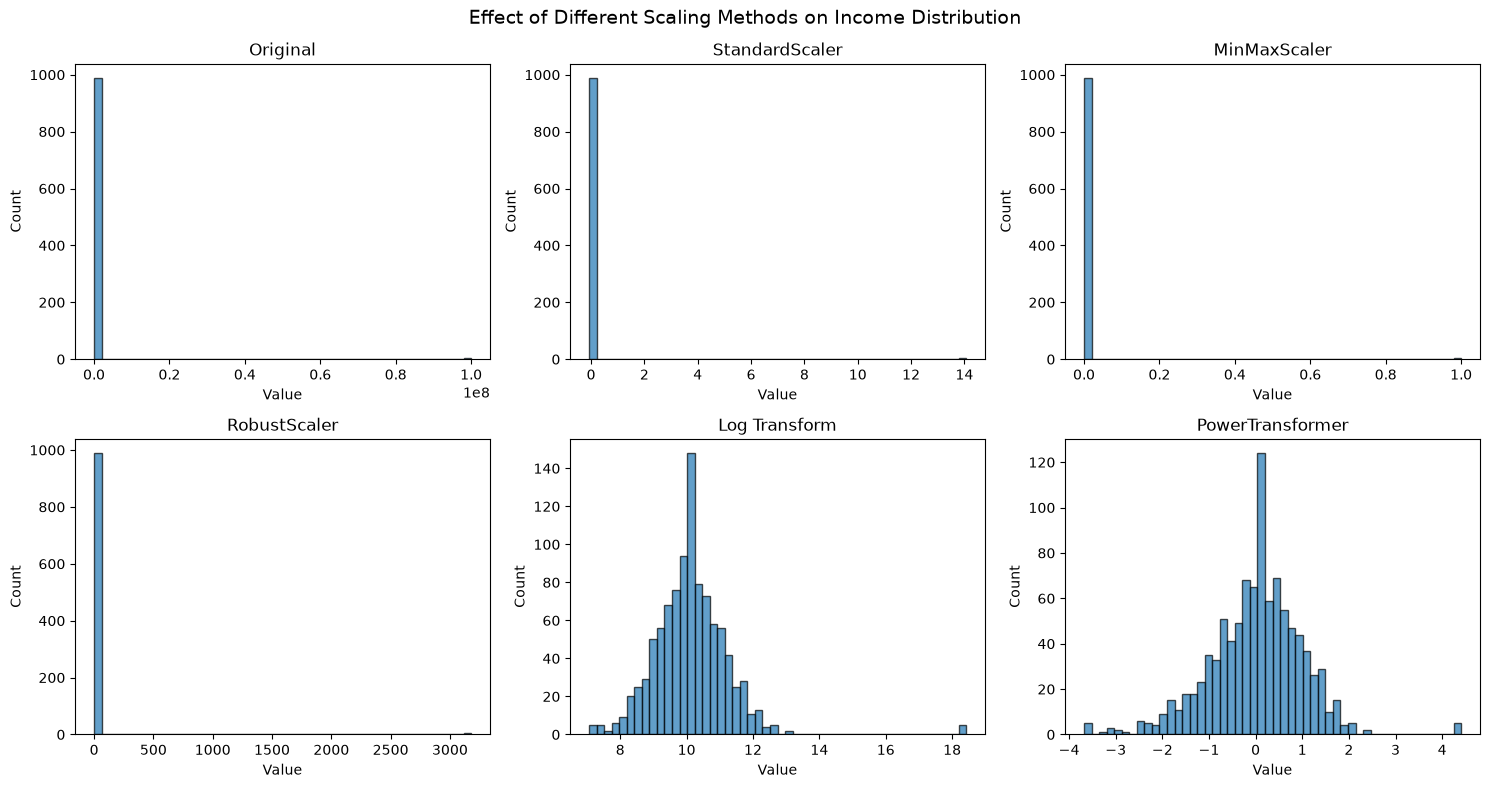

Train mean: [-0.  0.  0.  0.]
Train std:  [1. 1. 1. 1.]
Test mean:  [ 0.041  0.103 -0.065 -0.077]


In [6]:
import matplotlib.pyplot as plt

# Use income as example (skewed, with outliers)
data = df_out['income'].values.reshape(-1, 1)

scalers = {
    'Original':          data,
    'StandardScaler':    StandardScaler().fit_transform(data),
    'MinMaxScaler':      MinMaxScaler().fit_transform(data),
    'RobustScaler':      RobustScaler().fit_transform(data),
    'Log Transform':     np.log1p(data),
    'PowerTransformer':  PowerTransformer(method='yeo-johnson').fit_transform(data),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, scaled) in zip(axes.flat, scalers.items()):
    ax.hist(scaled.ravel(), bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
plt.suptitle('Effect of Different Scaling Methods on Income Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ===== Important: fit on train, transform test =====
# NEVER fit on test data that's data leakage!
X = df_out[['age', 'income', 'score', 'experience']].values
y = df_out['hired'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform train
X_test_scaled  = scaler.transform(X_test)         # ONLY transform test

print(f'Train mean: {X_train_scaled.mean(axis=0).round(3)}')
print(f'Train std:  {X_train_scaled.std(axis=0).round(3)}')
print(f'Test mean:  {X_test_scaled.mean(axis=0).round(3)}')

---
## 5. Encoding Categorical Variables <a id='5'></a>

ML algorithms work with numbers categorical data must be encoded.

| Encoding | When to use | Pro | Con |
|----------|------------|-----|-----|
| **Label Encoding** | Ordinal categories, tree models | Simple | Implies order for non-ordinal |
| **One-Hot Encoding** | Nominal, low cardinality (<20 unique) | No false order | High dimensionality |
| **Ordinal Encoding** | Ordered categories | Preserves order | Manual order needed |
| **Target Encoding** | High cardinality | Low dim, informative | Risk of data leakage |
| **Frequency Encoding** | High cardinality | Simple | Loses category identity |
| **Binary Encoding** | High cardinality | Low dim | Less interpretable |

In [7]:
# ===== Label Encoding =====
le = LabelEncoder()
df_out['city_label'] = le.fit_transform(df_out['city'])
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# ===== Ordinal Encoding (with specified order) =====
edu_order = [['High School', 'Bachelor', 'Master', 'PhD']]
oe = OrdinalEncoder(categories=edu_order)
df_out['education_ordinal'] = oe.fit_transform(df_out[['education']])
print('\nOrdinal encoding (education):')
print(df_out[['education', 'education_ordinal']].drop_duplicates().sort_values('education_ordinal'))

# ===== One-Hot Encoding =====
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
city_ohe = ohe.fit_transform(df_out[['city']])
city_cols = ohe.get_feature_names_out(['city'])
df_ohe = pd.DataFrame(city_ohe, columns=city_cols, index=df_out.index)
df_out = pd.concat([df_out, df_ohe], axis=1)
print('\nOne-hot encoded columns:', list(city_cols))

# Pandas get_dummies (simpler for notebooks)
dummies = pd.get_dummies(df['city'], prefix='city', drop_first=True)  # drop first avoids multicollinearity
print(dummies.head())

# ===== Target / Mean Encoding =====
# Mean of target for each category useful for high cardinality
# Must be done on training data only!
target_means = df_out.groupby('city')['hired'].mean()
df_out['city_target_encoded'] = df_out['city'].map(target_means)
print('\nTarget encoding:', target_means.to_dict())

# ===== Frequency Encoding =====
freq_map = df_out['city'].value_counts(normalize=True)
df_out['city_freq'] = df_out['city'].map(freq_map)
print('\nFrequency encoding:', freq_map.to_dict())

Label encoding: {'Chicago': np.int64(0), 'Houston': np.int64(1), 'LA': np.int64(2), 'NYC': np.int64(3), 'Phoenix': np.int64(4)}

Ordinal encoding (education):
     education  education_ordinal
1  High School                0.0
0     Bachelor                1.0
4       Master                2.0
5          PhD                3.0

One-hot encoded columns: ['city_Chicago', 'city_Houston', 'city_LA', 'city_NYC', 'city_Phoenix']
   city_Houston  city_LA  city_NYC  city_Phoenix
0         False    False     False         False
1         False    False     False         False
2         False    False      True         False
3         False     True     False         False
4         False     True     False         False

Target encoding: {'Chicago': 0.32682926829268294, 'Houston': 0.2931937172774869, 'LA': 0.265, 'NYC': 0.27450980392156865, 'Phoenix': 0.31958762886597936}

Frequency encoding: {'Chicago': 0.2062374245472837, 'NYC': 0.2052313883299799, 'LA': 0.2012072434607646, 'Phoenix': 0.19517

---
## 6. Feature Engineering <a id='6'></a>

In [8]:
df_feat = df_out.copy()

# ===== Domain-based features =====
df_feat['income_per_year_exp'] = df_feat['income'] / (df_feat['experience'] + 1)
df_feat['age_to_exp_ratio']    = df_feat['age'] / (df_feat['experience'] + 1)
df_feat['is_senior']           = (df_feat['experience'] > 10).astype(int)
df_feat['score_bucket']        = pd.cut(df_feat['score'], bins=[0,50,70,85,100], labels=['Low','Mid','High','Top'])

# ===== Polynomial features =====
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
numerical = df_feat[['age','experience','score']].dropna()
poly_features = poly.fit_transform(numerical)
poly_cols = poly.get_feature_names_out(['age','experience','score'])
print(f'Original: 3 features → Polynomial degree 2: {len(poly_cols)} features')
print('Sample poly features:', list(poly_cols[:8]))

# ===== Interaction features =====
df_feat['age_x_experience'] = df_feat['age'] * df_feat['experience']
df_feat['log_income']       = np.log1p(df_feat['income'])
df_feat['sqrt_score']       = np.sqrt(df_feat['score'].clip(0))

# ===== Binning / Discretization =====
df_feat['age_group'] = pd.cut(
    df_feat['age'],
    bins=[0, 25, 35, 45, 60, 120],
    labels=['Early Career', 'Mid Career', 'Senior', 'Late Career', 'Expert']
)

# ===== Feature selection using variance =====
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif

# Remove features with low variance (near-constant)
num_cols = ['age', 'income', 'experience', 'score']
sel = VarianceThreshold(threshold=0.1)
sel.fit(df_feat[num_cols].dropna())
print(f'Features retained after variance threshold: {sel.get_feature_names_out(num_cols)}')

print('\nNew feature sample:')
print(df_feat[['age', 'income', 'experience', 'income_per_year_exp', 'is_senior']].head())

Original: 3 features → Polynomial degree 2: 9 features
Sample poly features: ['age', 'experience', 'score', 'age^2', 'age experience', 'age score', 'experience^2', 'experience score']
Features retained after variance threshold: ['age' 'income' 'experience' 'score']

New feature sample:
         age        income  experience  income_per_year_exp  is_senior
0  40.960570  89264.168397          22          3881.050800          1
1  33.340828  23598.877822          10          2145.352529          0
2  42.772262  23379.862874          27           834.995103          1
3  53.276358  11534.100901          13           823.864350          1
4  32.190160  44277.118652          29          1475.903955          1


---
## 7. Handling Imbalanced Data <a id='7'></a>

Class imbalance occurs when one class is much more frequent than others (e.g., 99% non-fraud, 1% fraud).

### Techniques:
| Method | Approach |
|--------|----------|
| **Oversampling (SMOTE)** | Generate synthetic minority samples |
| **Undersampling** | Remove majority samples |
| **Class weights** | Penalize misclassifying minority class |
| **Threshold tuning** | Adjust decision threshold |

In [9]:
try:
    from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler, TomekLinks
    from imblearn.combine import SMOTETomek, SMOTEENN

    # Imbalanced dataset
    X_imb = df_out[['age', 'income', 'score', 'experience']].dropna().values
    y_imb = np.random.choice([0, 1], len(X_imb), p=[0.95, 0.05])
    print(f'Before SMOTE Class 0: {(y_imb==0).sum()}, Class 1: {(y_imb==1).sum()}')

    # SMOTE: Synthetic Minority Over-sampling Technique
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_imb, y_imb)
    print(f'After SMOTE  Class 0: {(y_resampled==0).sum()}, Class 1: {(y_resampled==1).sum()}')

    # SMOTETomek: SMOTE + remove noisy samples
    smt = SMOTETomek(random_state=42)
    X_smt, y_smt = smt.fit_resample(X_imb, y_imb)
    print(f'After SMOTETomek Total: {len(y_smt)}')

except ImportError:
    print('Install: pip install imbalanced-learn')

# Class weights (no resampling needed)
from sklearn.utils.class_weight import compute_class_weight
y_sample = np.array([0,0,0,0,0,0,0,0,0,1])
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_sample), y=y_sample)
print(f'\nClass weights: {dict(zip([0,1], weights))}')

Before SMOTE Class 0: 942, Class 1: 52
After SMOTE  Class 0: 942, Class 1: 942
After SMOTETomek Total: 1548

Class weights: {0: np.float64(0.5555555555555556), 1: np.float64(5.0)}


---
## 8. Data Splitting <a id='8'></a>

Proper train/val/test splitting is **fundamental** to unbiased evaluation.

In [10]:
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, GroupKFold

X = df_out[['age', 'income', 'score', 'experience']].dropna().values
y = df_out.loc[df_out[['age', 'income', 'score', 'experience']].notna().all(axis=1), 'hired'].values

# ===== Simple train/val/test split =====
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

# ===== Stratified split (preserves class ratio) =====
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'\nStratified Train class ratio: {y_train_s.mean():.3f}, Test: {y_test_s.mean():.3f}')

# ===== K-Fold Cross Validation =====
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f'Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}')

# ===== Time Series Split (no future data leakage) =====
tscv = TimeSeriesSplit(n_splits=5)
print('\nTime Series CV splits:')
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f'Fold {fold+1}: train=[{train_idx[0]}:{train_idx[-1]}] val=[{val_idx[0]}:{val_idx[-1]}]')

Train: 596, Val: 199, Test: 199

Stratified Train class ratio: 0.296, Test: 0.296
Fold 1: train=795, val=199
Fold 2: train=795, val=199
Fold 3: train=795, val=199
Fold 4: train=795, val=199
Fold 5: train=796, val=198

Time Series CV splits:
Fold 1: train=[0:168] val=[169:333]
Fold 2: train=[0:333] val=[334:498]
Fold 3: train=[0:498] val=[499:663]
Fold 4: train=[0:663] val=[664:828]
Fold 5: train=[0:828] val=[829:993]


---
## 9. Sklearn Pipelines <a id='9'></a>

Pipelines chain preprocessing steps + model together **prevents data leakage** and makes code production-ready.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Feature groups
numerical_features    = ['age', 'income', 'score', 'experience']
categorical_features  = ['education', 'city']

# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,   numerical_features),
    ('cat', categorical_pipeline, categorical_features),
], remainder='drop')

# Full pipeline with model
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42))
])

# Train and evaluate
X_raw    = df[numerical_features + categorical_features]
y_target = df['hired']

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_target, test_size=0.2, random_state=42)

full_pipeline.fit(X_train, y_train)  # pipeline handles all preprocessing
y_pred = full_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

# Save pipeline
import pickle
with open('/tmp/preprocessing_pipeline.pkl', 'wb') as f:
    pickle.dump(full_pipeline, f)
print('Pipeline saved!')

              precision    recall  f1-score   support

           0       0.70      1.00      0.82       143
           1       0.00      0.00      0.00        61

    accuracy                           0.70       204
   macro avg       0.35      0.50      0.41       204
weighted avg       0.49      0.70      0.58       204

Pipeline saved!


---
## 10. Additional Learning Resources <a id='10'></a>

### Documentation
- **Scikit-learn Preprocessing**: https://scikit-learn.org/stable/modules/preprocessing.html
- **Scikit-learn Pipelines**: https://scikit-learn.org/stable/modules/compose.html
- **imbalanced-learn**: https://imbalanced-learn.org/stable/

### Papers
- **SMOTE** (Chawla et al., 2002): https://arxiv.org/abs/1106.1813
- **ADASYN** (He et al., 2008): https://ieeexplore.ieee.org/document/4633969
- **Isolation Forest** (Liu et al., 2008): https://ieeexplore.ieee.org/document/4781136

### Books
- **Hands-On Machine Learning** (Ch. 2) Aurélien Géron: https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/
- **Feature Engineering for Machine Learning** Alice Zheng & Amanda Casari: https://www.oreilly.com/library/view/feature-engineering-for/9781491953235/

### Courses
- **Kaggle: Feature Engineering**: https://www.kaggle.com/learn/feature-engineering
- **Kaggle: Intermediate ML**: https://www.kaggle.com/learn/intermediate-machine-learning
- **Google: Data Prep for ML**: https://developers.google.com/machine-learning/data-prep